# Experiment: TCP Video-Aware Adaptive Batching

Objective:
- Rebuild the baseline around a shared TCP batching simulator and actual H.264 frame traces.
- Keep the research scope TCP-centric while borrowing video-aware importance ideas from packet trimming literature.
- Compare `immediate`, `fixed_size`, `fixed_time`, `fixed_hybrid`, `heuristic_frame_aware`, and `ml_regression_adaptive`.


In [1]:
from __future__ import annotations

import importlib.util
import json
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
}

missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

def resolve_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    return start

REPO_ROOT = resolve_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tcp_batching_core import (
    DEFAULT_SEED,
    FIXED_BATCH_GRID,
    FIXED_FLUSH_GRID_MS,
    PolicyConfig,
    StaticFileConfig,
    TransportConfig,
    VideoTraceConfig,
    build_policy_features,
    fixed_sweep,
    generate_workload,
    pick_oracle,
    run_simulation,
    scenario_id,
    score_candidate_row,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
np.random.seed(DEFAULT_SEED)

OUTPUT_DIR = REPO_ROOT / "output" / "jupyter-notebook"
ASSET_DIR = OUTPUT_DIR / "assets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)
TRACE_PATH = REPO_ROOT / "data" / "video-traces" / "bbb_720p_trace.csv"

def finalize_figure(fig) -> None:
    try:
        from IPython import get_ipython
        shell = get_ipython()
    except Exception:
        shell = None
    if shell is not None and shell.__class__.__name__ == "ZMQInteractiveShell":
        plt.show()
    else:
        plt.close(fig)

print(json.dumps({
    "python": sys.version.split()[0],
    "cli_hint": "py -3.9 -m jupyterlab",
    "repo_root": str(REPO_ROOT),
    "trace_path": str(TRACE_PATH),
    "output_dir": str(OUTPUT_DIR),
}, indent=2))


{
  "python": "3.9.13",
  "cli_hint": "py -3.9 -m jupyterlab",
  "repo_root": "C:\\git\\network",
  "trace_path": "C:\\git\\network\\data\\video-traces\\bbb_720p_trace.csv",
  "output_dir": "C:\\git\\network\\output\\jupyter-notebook"
}


## Experiment Scope

- Workloads: `static_file`, `video_stream_trace`
- Shared simulator source: `tcp_batching_core.py`
- Video source: `data/video-traces/bbb_720p_trace.csv` extracted from a 10-second 720p Big Buck Bunny sample
- Core metrics:
  - Network: `latency_mean_ms`, `latency_p95_ms`, `throughput_mbps`, `goodput_bytes`, `flush_count`
  - Video utility: `deadline_miss_ms_sum`, `late_frame_ratio`, `keyframe_late_ratio`, `decodable_gop_ratio`, `useful_goodput_bytes`
- Success target:
  - `static_file` should reward batching efficiency.
  - `video_stream_trace` should reveal when frame-aware flushing protects useful playback.


In [2]:
assert TRACE_PATH.exists(), f"Missing trace CSV: {TRACE_PATH}"
trace_df = pd.read_csv(TRACE_PATH)
assert trace_df["pts_ms"].is_monotonic_increasing
assert set(trace_df["frame_type"].unique()) <= {"I", "P", "B"}

def make_static(chunk_size: int, rtt_ms: float, bandwidth_mbps: float, delayed_ack_ms: float):
    return (
        StaticFileConfig(file_size_bytes=16 * 1024 * 1024, chunk_size_bytes=chunk_size),
        TransportConfig(rtt_ms=rtt_ms, bandwidth_mbps=bandwidth_mbps, delayed_ack_ms=delayed_ack_ms),
    )

def make_video(playback_buffer_ms: float, rtt_ms: float, bandwidth_mbps: float, delayed_ack_ms: float):
    return (
        VideoTraceConfig(trace_csv_path=TRACE_PATH, playback_buffer_ms=playback_buffer_ms),
        TransportConfig(rtt_ms=rtt_ms, bandwidth_mbps=bandwidth_mbps, delayed_ack_ms=delayed_ack_ms),
    )

STATIC_SCENARIOS = [
    make_static(chunk_size, rtt_ms, bandwidth_mbps, delayed_ack_ms)
    for chunk_size in [1024, 4096, 16384]
    for rtt_ms in [10, 50]
    for bandwidth_mbps in [5, 20]
    for delayed_ack_ms in [10, 40]
]
VIDEO_SCENARIOS = [
    make_video(playback_buffer_ms, rtt_ms, bandwidth_mbps, delayed_ack_ms)
    for playback_buffer_ms in [33, 50]
    for rtt_ms in [10, 50]
    for bandwidth_mbps in [5, 20]
    for delayed_ack_ms in [10, 40]
]
SCENARIOS = STATIC_SCENARIOS + VIDEO_SCENARIOS
SCENARIO_LOOKUP = {
    scenario_id(workload_cfg, transport_cfg): (workload_cfg, transport_cfg)
    for workload_cfg, transport_cfg in SCENARIOS
}

REFERENCE_SCENARIOS = {
    "static_reference": make_static(4096, 50, 20, 40),
    "video_reference": make_video(50, 10, 5, 40),
}

BASELINE_POLICIES = {
    "immediate": PolicyConfig("immediate"),
    "fixed_size_8192": PolicyConfig("fixed_size", batch_bytes=8192),
    "fixed_time_10ms": PolicyConfig("fixed_time", flush_interval_ms=10.0),
    "fixed_hybrid_8192_10ms": PolicyConfig("fixed_hybrid", batch_bytes=8192, flush_interval_ms=10.0),
    "heuristic_frame_aware": PolicyConfig("heuristic_frame_aware"),
}

scenario_overview = pd.DataFrame(
    [
        {
            "label": label,
            "scenario_id": scenario_id(workload_cfg, transport_cfg),
            "workload_kind": "static_file" if isinstance(workload_cfg, StaticFileConfig) else "video_stream_trace",
            "transport_rtt_ms": transport_cfg.rtt_ms,
            "transport_bandwidth_mbps": transport_cfg.bandwidth_mbps,
            "transport_delayed_ack_ms": transport_cfg.delayed_ack_ms,
            "extra": getattr(workload_cfg, "chunk_size_bytes", getattr(workload_cfg, "playback_buffer_ms", None)),
        }
        for label, (workload_cfg, transport_cfg) in REFERENCE_SCENARIOS.items()
    ]
)
scenario_overview


,label,scenario_id,workload_kind,transport_rtt_ms,transport_bandwidth_mbps,transport_delayed_ack_ms,extra
0,static_reference,static_16777216_4096_50_20_40,static_file,50,20,40,4096
1,video_reference,video_bbb_720p_trace_50_1_10_5_40,video_stream_trace,10,5,40,50


In [3]:
sweep_df = fixed_sweep(SCENARIOS)
scored_sweep_df, oracle_df, score_bounds = pick_oracle(sweep_df)

scenario_rows = []
for workload_cfg, transport_cfg in SCENARIOS:
    scenario_key = scenario_id(workload_cfg, transport_cfg)
    features = build_policy_features(workload_cfg, transport_cfg)
    scenario_rows.append({
        **features,
        "scenario_id": scenario_key,
        "workload_kind": features["workload_kind"],
    })

scenario_frame = pd.DataFrame(scenario_rows)
train_df = scenario_frame.merge(
    oracle_df[["scenario_id", "batch_bytes", "flush_interval_ms", "objective_score"]],
    on="scenario_id",
    how="left",
)
feature_frame = pd.get_dummies(train_df.drop(columns=["scenario_id", "batch_bytes", "flush_interval_ms", "objective_score"]), dummy_na=True).fillna(0.0)

train_ids, holdout_ids = train_test_split(
    train_df["scenario_id"],
    test_size=0.30,
    random_state=DEFAULT_SEED,
    stratify=train_df["workload_kind"],
)
train_mask = train_df["scenario_id"].isin(train_ids)
holdout_mask = train_df["scenario_id"].isin(holdout_ids)

batch_model = RandomForestRegressor(n_estimators=200, random_state=DEFAULT_SEED)
flush_model = RandomForestRegressor(n_estimators=200, random_state=DEFAULT_SEED + 1)
batch_model.fit(feature_frame.loc[train_mask], train_df.loc[train_mask, "batch_bytes"])
flush_model.fit(feature_frame.loc[train_mask], train_df.loc[train_mask, "flush_interval_ms"])

def to_ml_policy(feature_row: pd.DataFrame) -> PolicyConfig:
    pred_batch = float(batch_model.predict(feature_row)[0])
    pred_flush = float(flush_model.predict(feature_row)[0])
    return PolicyConfig(
        "ml_regression_adaptive",
        batch_bytes=int(max(1, min(FIXED_BATCH_GRID, key=lambda item: abs(item - pred_batch)))),
        flush_interval_ms=float(max(0.0, min(FIXED_FLUSH_GRID_MS, key=lambda item: abs(item - pred_flush)))),
    )

ml_rows = []
for _, row in train_df.loc[holdout_mask].iterrows():
    scenario_key = row["scenario_id"]
    workload_cfg, transport_cfg = SCENARIO_LOOKUP[scenario_key]
    row_features = feature_frame.loc[[row.name]]
    ml_policy = to_ml_policy(row_features)
    ml_result = run_simulation(workload_cfg, transport_cfg, ml_policy)
    heuristic_result = run_simulation(workload_cfg, transport_cfg, PolicyConfig("heuristic_frame_aware"))
    oracle_row = oracle_df.loc[oracle_df["scenario_id"] == scenario_key].iloc[0]
    bounds = score_bounds[scenario_key]
    reference_scores = scored_sweep_df.loc[scored_sweep_df["scenario_id"] == scenario_key, "objective_score"]

    for comparison, result in [
        ("ml_regression_adaptive", ml_result),
        ("heuristic_frame_aware", heuristic_result),
    ]:
        candidate_score = score_candidate_row(result, bounds)
        ml_rows.append({
            **result,
            "comparison": comparison,
            "oracle_score": float(oracle_row["objective_score"]),
            "candidate_score": candidate_score,
            "oracle_score_gap": float(oracle_row["objective_score"]) - candidate_score,
            "candidate_rank_vs_fixed_sweep": int(1 + (reference_scores > candidate_score).sum()),
        })

ml_eval_df = pd.DataFrame(ml_rows)

def reference_policy_rows() -> pd.DataFrame:
    rows = []
    for label, (workload_cfg, transport_cfg) in REFERENCE_SCENARIOS.items():
        reference_features = pd.get_dummies(pd.DataFrame([build_policy_features(workload_cfg, transport_cfg)]), dummy_na=True).fillna(0.0)
        aligned = reference_features.reindex(columns=feature_frame.columns, fill_value=0.0)
        ml_policy = to_ml_policy(aligned)
        policy_map = dict(BASELINE_POLICIES)
        policy_map["ml_regression_adaptive"] = ml_policy
        for comparison, policy_cfg in policy_map.items():
            result = run_simulation(workload_cfg, transport_cfg, policy_cfg)
            scenario_key = result["scenario_id"]
            candidate_score = score_candidate_row(result, score_bounds[scenario_key])
            oracle_score = float(oracle_df.loc[oracle_df["scenario_id"] == scenario_key, "objective_score"].iloc[0])
            rows.append({
                **result,
                "reference_label": label,
                "comparison": comparison,
                "candidate_score": candidate_score,
                "oracle_score_gap": oracle_score - candidate_score,
            })
    return pd.DataFrame(rows)

reference_results = reference_policy_rows()

summary_columns = [
    "reference_label",
    "workload_kind",
    "comparison",
    "latency_mean_ms",
    "latency_p95_ms",
    "throughput_mbps",
    "goodput_bytes",
    "flush_count",
    "late_frame_ratio",
    "keyframe_late_ratio",
    "decodable_gop_ratio",
    "useful_goodput_bytes",
    "oracle_score_gap",
]
reference_summary = reference_results[summary_columns].sort_values(["reference_label", "comparison"]).reset_index(drop=True)
reference_summary.head(12)


,reference_label,workload_kind,comparison,latency_mean_ms,latency_p95_ms,throughput_mbps,goodput_bytes,flush_count,late_frame_ratio,keyframe_late_ratio,decodable_gop_ratio,useful_goodput_bytes,oracle_score_gap
0,static_reference,static_file,fixed_hybrid_8192_10ms,28867.256600,54832.16530,2.317658,16777216.0,2048,0.000000,0.0,0.0,16777216.0,0.515007
1,static_reference,static_file,fixed_size_8192,28867.256600,54832.16530,2.317658,16777216.0,2048,0.000000,0.0,0.0,16777216.0,0.515007
2,static_reference,static_file,fixed_time_10ms,3693.563744,6868.16250,18.523300,16777216.0,21,0.000000,0.0,0.0,16777216.0,0.000000
3,static_reference,static_file,heuristic_frame_aware,6479.425400,12302.02610,10.236535,16777216.0,256,0.000000,0.0,0.0,16777216.0,0.000000
4,static_reference,static_file,immediate,54466.387400,103462.16150,1.230104,16777216.0,4096,0.000000,0.0,0.0,16777216.0,0.750000
5,static_reference,static_file,ml_regression_adaptive,6479.425400,12302.02610,10.236535,16777216.0,256,0.000000,0.0,0.0,16777216.0,0.000000
6,video_reference,video_stream_trace,fixed_hybrid_8192_10ms,22.217443,26.96760,0.773177,965199.0,300,0.016667,1.0,0.0,796986.0,0.001882
7,video_reference,video_stream_trace,fixed_size_8192,116.819975,200.27440,0.773535,965199.0,52,0.663333,1.0,0.0,604836.0,0.500000
8,video_reference,video_stream_trace,fixed_time_10ms,24.017443,36.01064,0.773177,965199.0,300,0.023333,1.0,0.0,795658.0,0.284365
9,video_reference,video_stream_trace,heuristic_frame_aware,26.924110,26.11248,0.773332,965199.0,300,0.016667,1.0,0.0,796986.0,0.000200


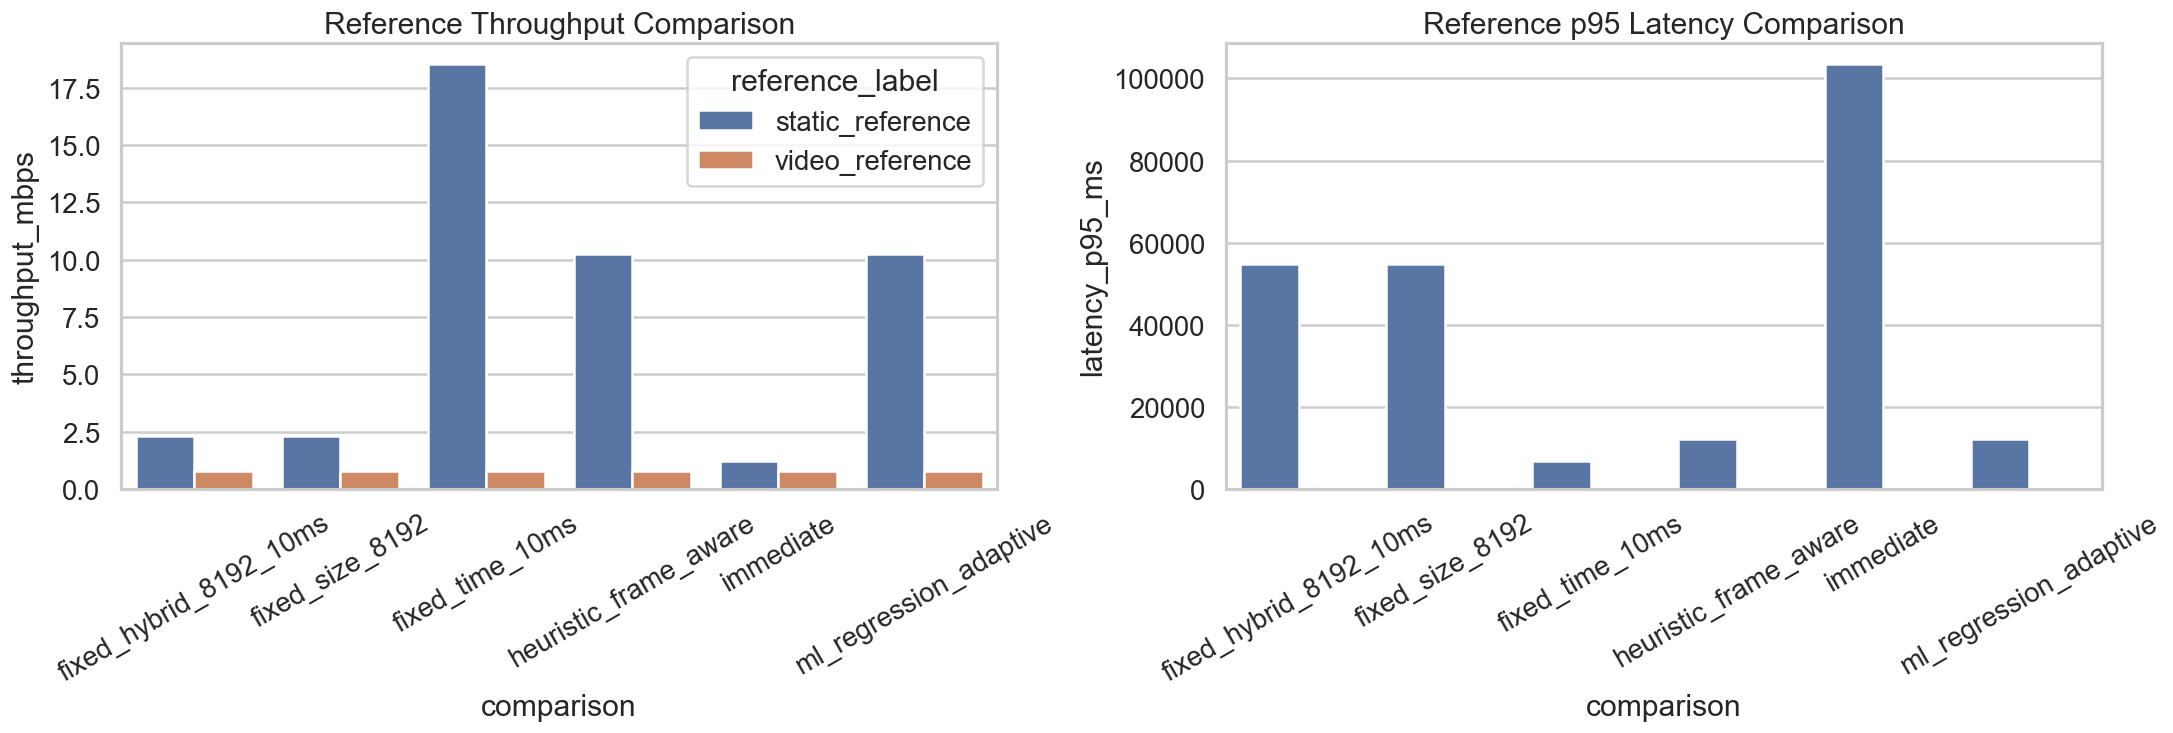

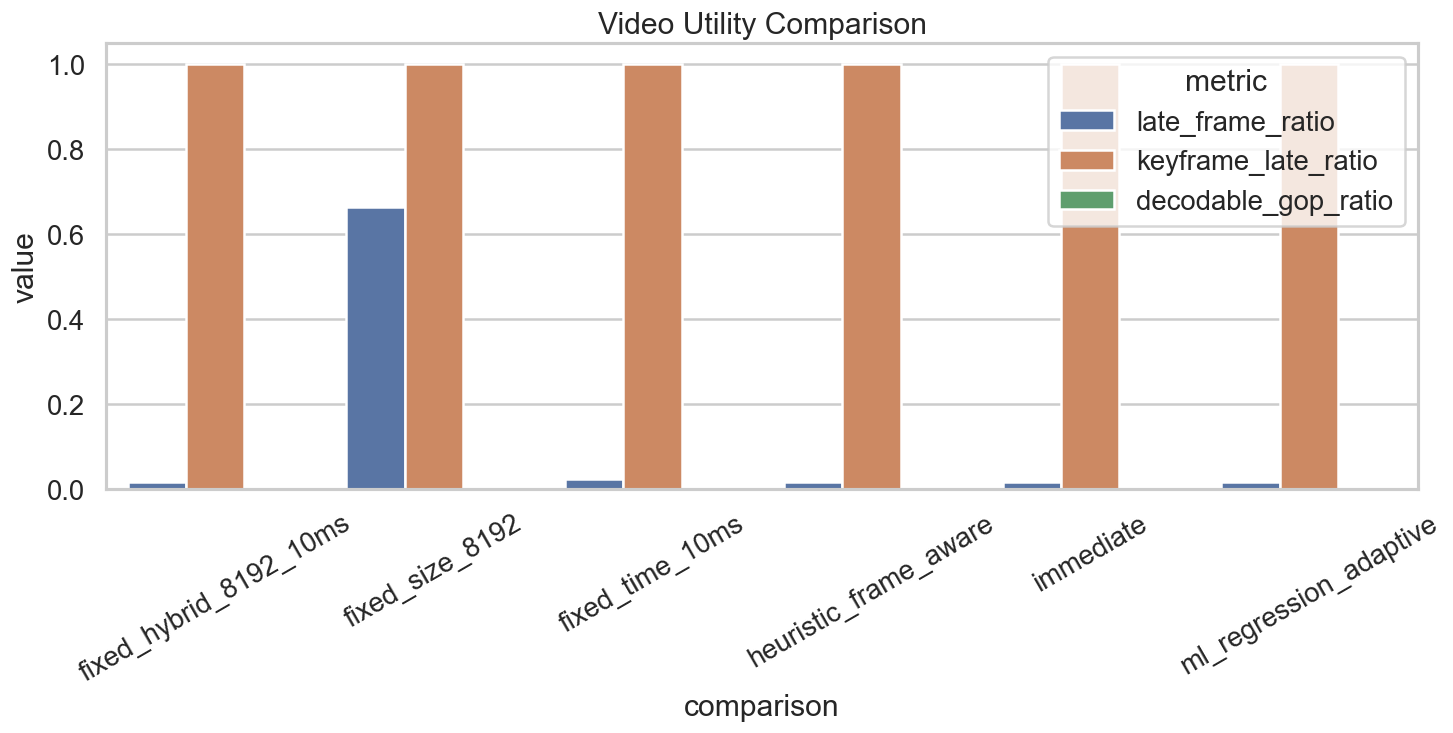

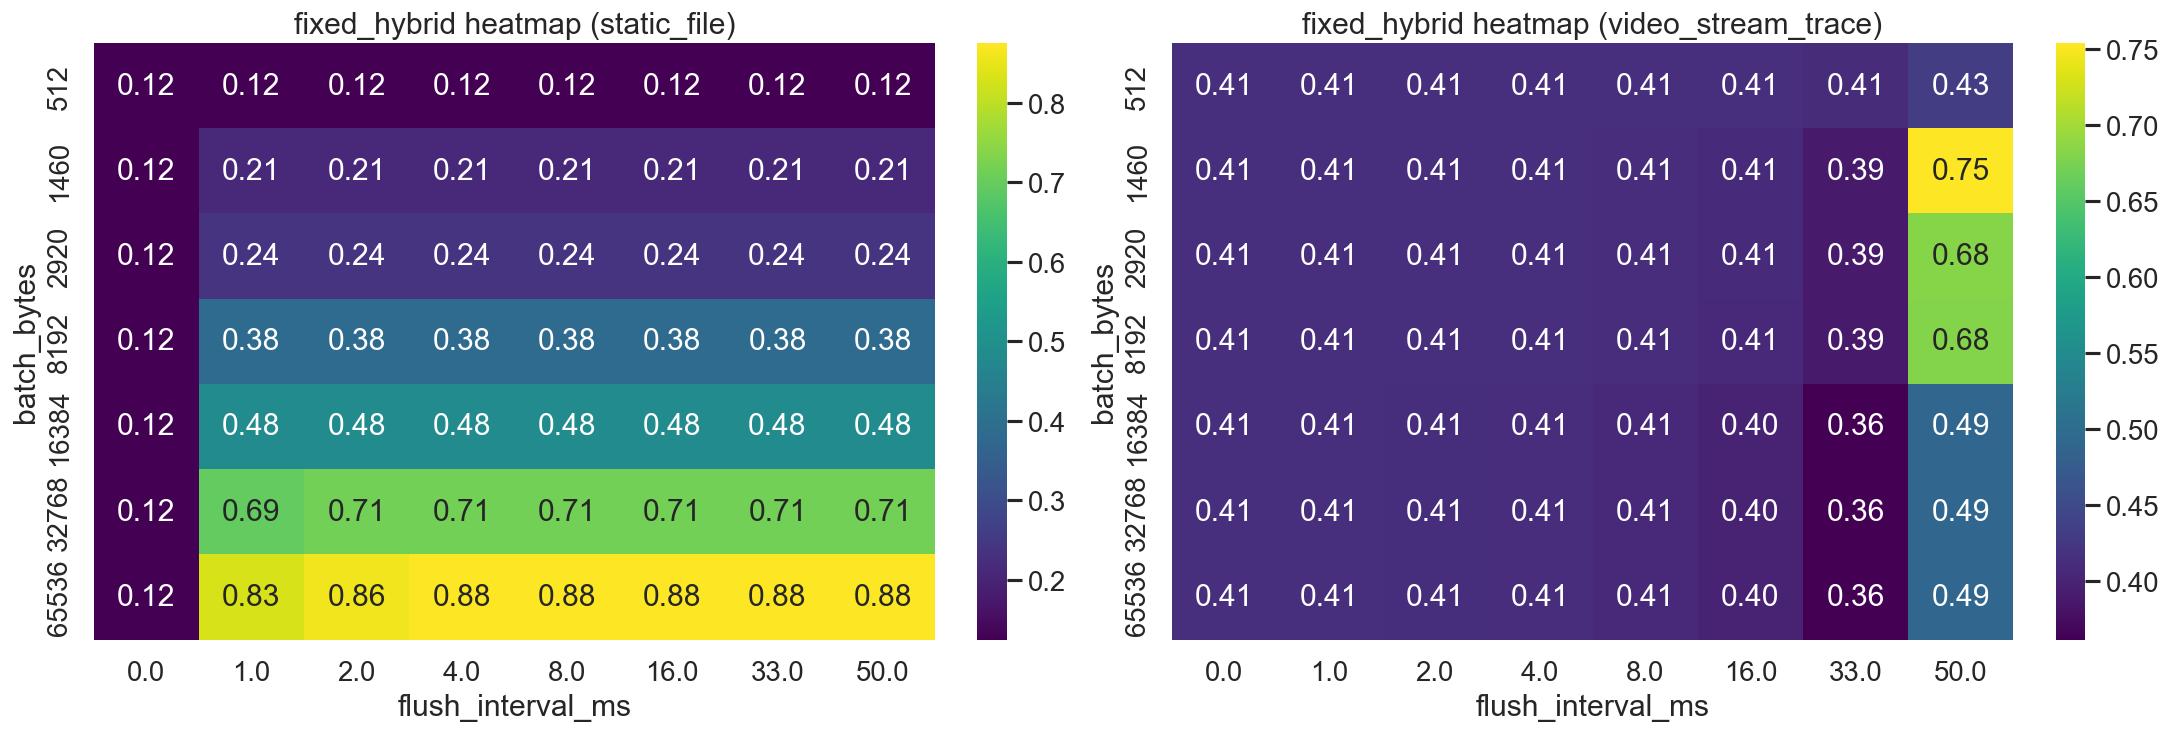

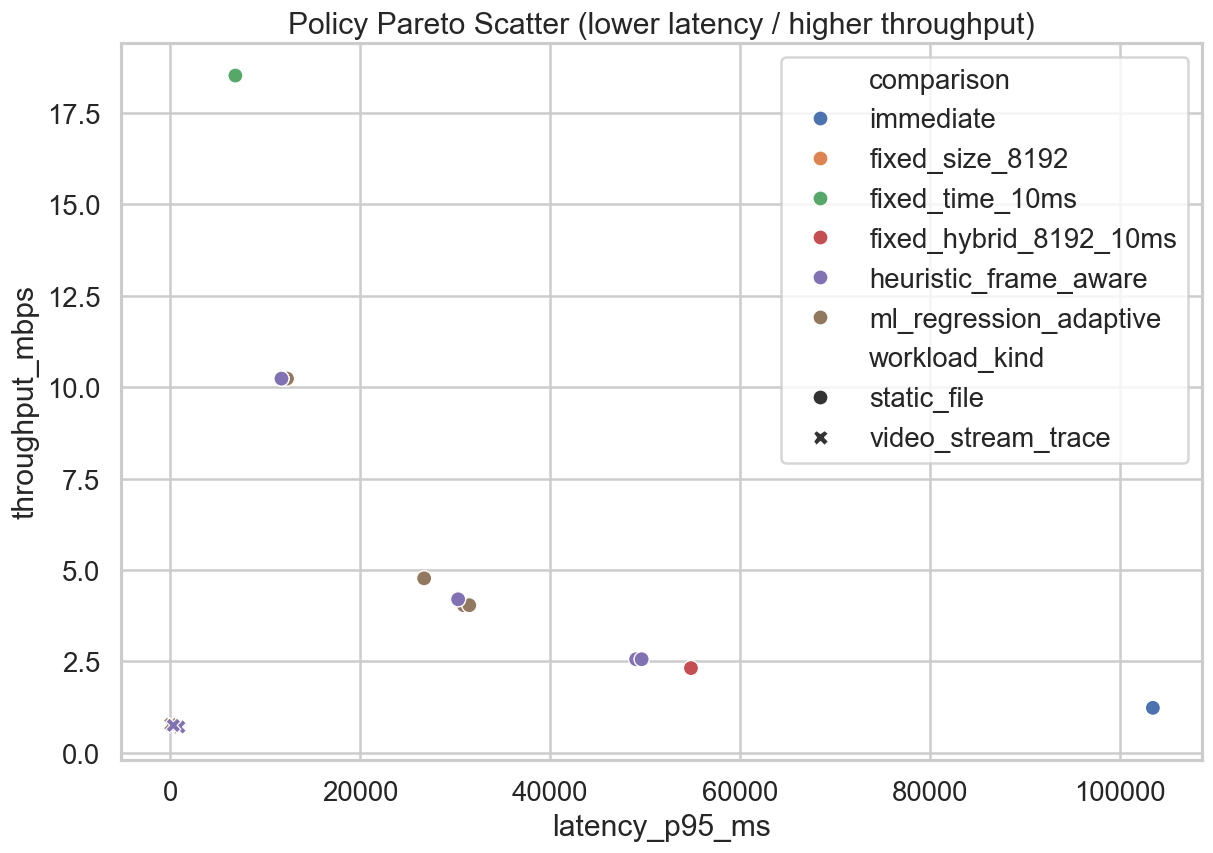

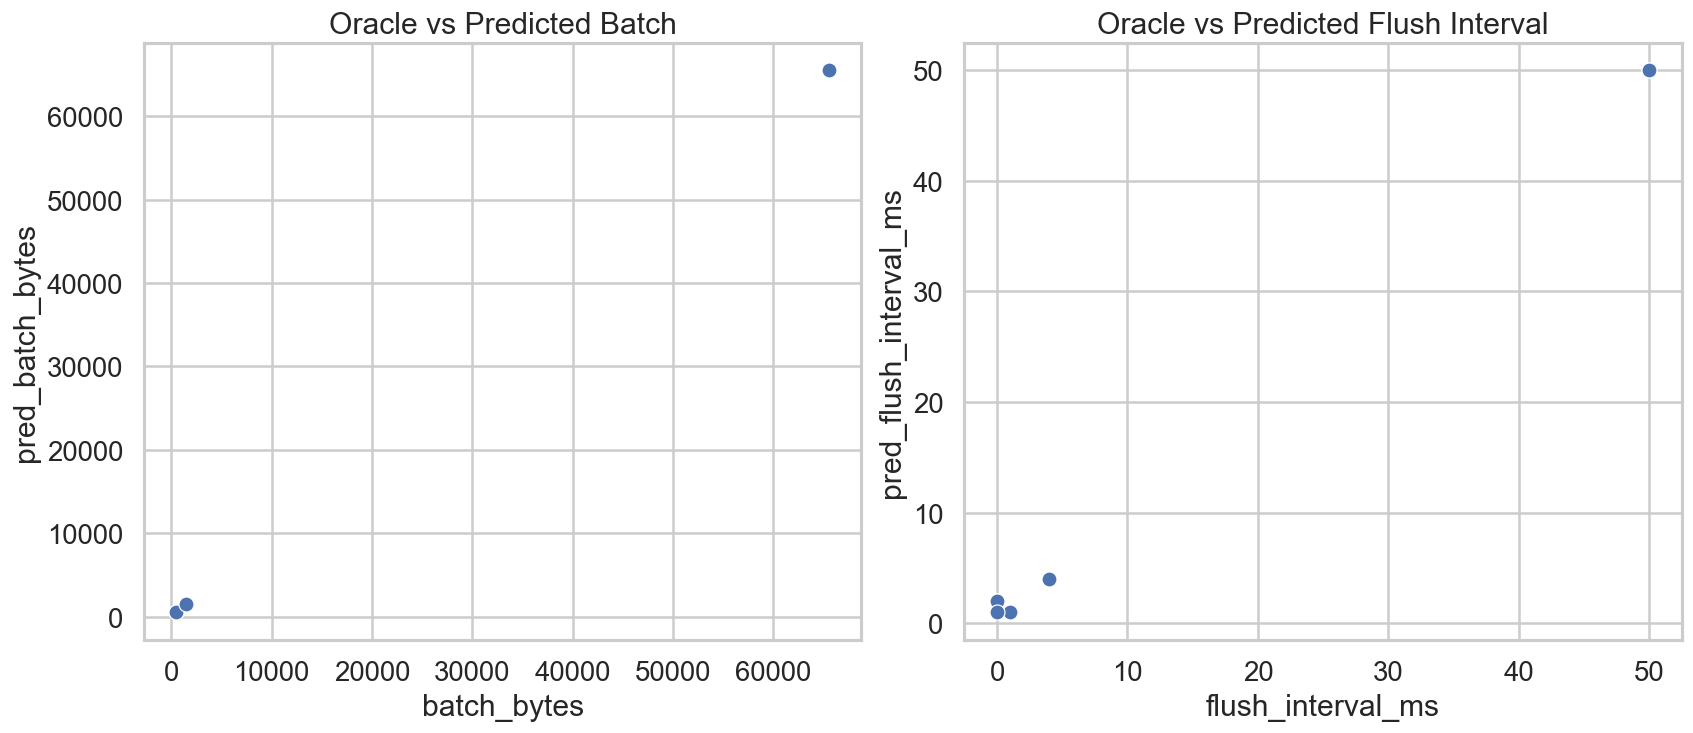

saved:
- C:\git\network\output\jupyter-notebook\assets\reference_policy_overview.png
- C:\git\network\output\jupyter-notebook\assets\video_utility_comparison.png
- C:\git\network\output\jupyter-notebook\assets\fixed_batch_heatmap.png
- C:\git\network\output\jupyter-notebook\assets\policy_pareto_scatter.png
- C:\git\network\output\jupyter-notebook\assets\oracle_vs_prediction_scatter.png
- C:\git\network\output\jupyter-notebook\assets\reference_summary.csv
- C:\git\network\output\jupyter-notebook\assets\fixed_sweep_results.csv
- C:\git\network\output\jupyter-notebook\assets\oracle_selection.csv
- C:\git\network\output\jupyter-notebook\assets\ml_eval_results.csv

holdout summary:
comparison
heuristic_frame_aware     0.3506
ml_regression_adaptive    0.0000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
sns.barplot(data=reference_summary, x="comparison", y="throughput_mbps", hue="reference_label", ax=axes[0])
axes[0].set_title("Reference Throughput Comparison")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(data=reference_summary, x="comparison", y="latency_p95_ms", hue="reference_label", ax=axes[1])
axes[1].set_title("Reference p95 Latency Comparison")
axes[1].tick_params(axis="x", rotation=30)
if axes[1].legend_ is not None:
    axes[1].legend_.remove()
reference_path = ASSET_DIR / "reference_policy_overview.png"
fig.savefig(reference_path, bbox_inches="tight")
finalize_figure(fig)

video_reference = reference_summary[reference_summary["workload_kind"] == "video_stream_trace"].copy()
utility_source = video_reference.melt(
    id_vars=["comparison"],
    value_vars=["late_frame_ratio", "keyframe_late_ratio", "decodable_gop_ratio"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
sns.barplot(data=utility_source, x="comparison", y="value", hue="metric", ax=ax)
ax.set_title("Video Utility Comparison")
ax.tick_params(axis="x", rotation=30)
utility_path = ASSET_DIR / "video_utility_comparison.png"
fig.savefig(utility_path, bbox_inches="tight")
finalize_figure(fig)

heatmap_source = scored_sweep_df.groupby(["workload_kind", "batch_bytes", "flush_interval_ms"], as_index=False)["objective_score"].mean()
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
for ax, workload_kind in zip(axes, ["static_file", "video_stream_trace"]):
    pivot = heatmap_source[heatmap_source["workload_kind"] == workload_kind].pivot(
        index="batch_bytes",
        columns="flush_interval_ms",
        values="objective_score",
    )
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis", ax=ax)
    ax.set_title(f"fixed_hybrid heatmap ({workload_kind})")
heatmap_path = ASSET_DIR / "fixed_batch_heatmap.png"
fig.savefig(heatmap_path, bbox_inches="tight")
finalize_figure(fig)

pareto_df = pd.concat(
    [
        reference_results[["comparison", "workload_kind", "latency_p95_ms", "throughput_mbps"]],
        ml_eval_df[["comparison", "workload_kind", "latency_p95_ms", "throughput_mbps"]],
    ],
    ignore_index=True,
)
fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
sns.scatterplot(
    data=pareto_df,
    x="latency_p95_ms",
    y="throughput_mbps",
    hue="comparison",
    style="workload_kind",
    ax=ax,
)
ax.set_title("Policy Pareto Scatter (lower latency / higher throughput)")
pareto_path = ASSET_DIR / "policy_pareto_scatter.png"
fig.savefig(pareto_path, bbox_inches="tight")
finalize_figure(fig)

holdout_oracle = train_df.loc[holdout_mask, ["scenario_id", "batch_bytes", "flush_interval_ms"]].copy()
holdout_predictions = []
for _, row in train_df.loc[holdout_mask].iterrows():
    pred = to_ml_policy(feature_frame.loc[[row.name]])
    holdout_predictions.append({
        "scenario_id": row["scenario_id"],
        "pred_batch_bytes": pred.batch_bytes,
        "pred_flush_interval_ms": pred.flush_interval_ms,
    })
prediction_df = holdout_oracle.merge(pd.DataFrame(holdout_predictions), on="scenario_id", how="left")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
sns.scatterplot(data=prediction_df, x="batch_bytes", y="pred_batch_bytes", ax=axes[0])
axes[0].set_title("Oracle vs Predicted Batch")
sns.scatterplot(data=prediction_df, x="flush_interval_ms", y="pred_flush_interval_ms", ax=axes[1])
axes[1].set_title("Oracle vs Predicted Flush Interval")
oracle_scatter_path = ASSET_DIR / "oracle_vs_prediction_scatter.png"
fig.savefig(oracle_scatter_path, bbox_inches="tight")
finalize_figure(fig)

reference_summary.to_csv(ASSET_DIR / "reference_summary.csv", index=False)
scored_sweep_df.to_csv(ASSET_DIR / "fixed_sweep_results.csv", index=False)
oracle_df.to_csv(ASSET_DIR / "oracle_selection.csv", index=False)
ml_eval_df.to_csv(ASSET_DIR / "ml_eval_results.csv", index=False)

print("saved:")
for path in [
    reference_path,
    utility_path,
    heatmap_path,
    pareto_path,
    oracle_scatter_path,
    ASSET_DIR / "reference_summary.csv",
    ASSET_DIR / "fixed_sweep_results.csv",
    ASSET_DIR / "oracle_selection.csv",
    ASSET_DIR / "ml_eval_results.csv",
]:
    print(f"- {path}")

print()
print("holdout summary:")
print(
    ml_eval_df.groupby("comparison")["oracle_score_gap"].mean().round(4).to_string()
)


## Validation Notes

- The notebook now treats the simulator as shared infrastructure instead of duplicating logic in-place.
- The streaming workload is trace-driven and frame-aware, which makes deadline-related metrics meaningful.
- `ml_regression_adaptive` is evaluated only after oracle labels are regenerated from the `fixed_hybrid` sweep.
